In [317]:
from environment import CoronagraphEnvironment
import hcipy
from hcipy import *
from matplotlib import pyplot as plt
import numpy as np
import os
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [534]:
import json
from pprint import pprint

path = r'jobs\20251022_171601\exp-fc1-minmax-ep10000-bs2048-lr1e-3-s42-h512-256-128'
path = r'jobs\20251110_122808\exp-fc1-zscore-ep10000-bs2048-lr1e-3-s42-h512-256-128'
# path = r'jobs\20251111_165459\exp-fc1-zscore-ep10000-bs2048-lr1e-3-s42-h512-256-128'
# path = r'jobs\20251115_225402\exp-fc1-zscore-ep10000-bs2048-lr1e-3-s42-h1024-512-256-images'
path = r"A:\Projects\DM + RL\RL\jobs\20251116_125958\exp-fc1-zscore-ep2500-bs65536-lr1e-3-s42-h1024-512-256-images"

metrics_path = path + r'\metrics.json'

with open(metrics_path, 'r', encoding='utf-8') as f:
    metrics_data = json.load(f)

pprint(metrics_data.keys())

dict_keys(['args', 'x_norm', 'y_norm', 'history', 'input_shape', 'output_dim', 'dataset_meta', 'train_job_meta'])


In [535]:
metrics_data['dataset_meta']

{'environment_config': {'telescope_diameter': 8.0,
  'oversizing_factor': 1.0666666666666667,
  'wavelength_sci': 2.2e-06,
  'num_modes': 25,
  'zero_magnitude_flux': 389999999.99999994,
  'stellar_magnitude': 5.0,
  'env_delta_t': 0.001,
  'pixels': 64,
  'num_iterations': 10,
  'coronagraph_charge': 6,
  'num_airy': 5,
  'pixels_per_spacial_res': 2,
  'num_noise_modes': 10,
  'diversity_enabled': True,
  'nudge_magnitude': 3e-07,
  'nudge_mode_indices': [3],
  'num_diversity_pairs': 1,
  'obs_noise_enabled': False,
  'obs_delta_t': 0.001,
  'include_slopes': True,
  'action_scale': 1e-08,
  'dm_clip': None,
  'lyot_fraction': 0.8,
  'basis': 'zernike'},
 'dataset_config': {'N': 220000,
  'delta_t': 0.001,
  'noise_enabled': False,
  'dm_random_noise': 1e-07,
  'dm_random_noise_std': 1e-07,
  'nudge_amplitude': 3e-07,
  'nudge_mode_index': 0,
  'save_checkpoints': None},
 'nudge_vector': [3e-07,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,

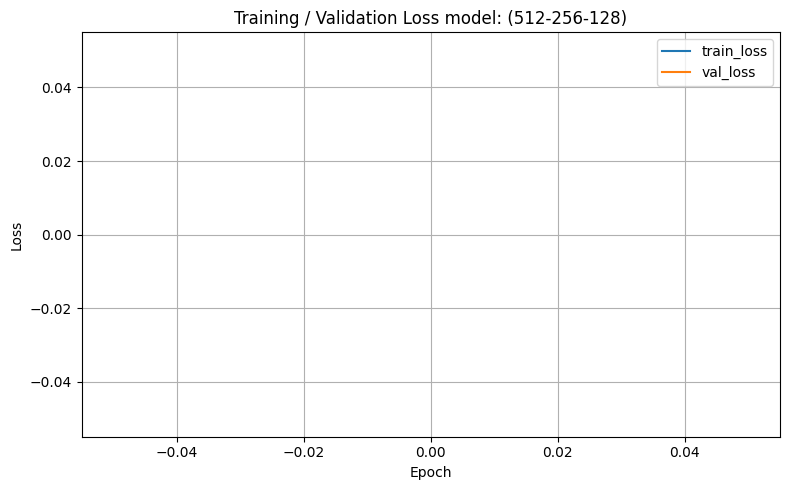

In [536]:
history = metrics_data['history']
train = history.get('train_loss', [])
val = history.get('val_loss', [])

plt.figure(figsize=(8,5))
plt.plot(range(1, len(train)+1), train, label='train_loss')
if val:
    plt.plot(range(1, len(val)+1), val, label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.title('Training / Validation Loss model: (512-256-128)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [538]:
import glob
import numpy as np

# search for .pth/.pt files in the experiment directory (uses existing `path` variable)
candidates = glob.glob(os.path.join(path, '*.pth')) + glob.glob(os.path.join(path, '*.pt'))
if not candidates:
    for root, _, files in os.walk(path):
        for f in files:
            if f.endswith(('.pth', '.pt')):
                candidates.append(os.path.join(root, f))

if not candidates:
    raise FileNotFoundError(f'No .pth/.pt files found under {path!r}')

checkpoint_path = max(candidates, key=os.path.getmtime)


In [539]:
metrics_data['y_norm']

{'mean': nan, 'std': nan}

In [540]:
metrics_data.keys()

dict_keys(['args', 'x_norm', 'y_norm', 'history', 'input_shape', 'output_dim', 'dataset_meta', 'train_job_meta'])

In [541]:
metrics_data['dataset_meta']

{'environment_config': {'telescope_diameter': 8.0,
  'oversizing_factor': 1.0666666666666667,
  'wavelength_sci': 2.2e-06,
  'num_modes': 25,
  'zero_magnitude_flux': 389999999.99999994,
  'stellar_magnitude': 5.0,
  'env_delta_t': 0.001,
  'pixels': 64,
  'num_iterations': 10,
  'coronagraph_charge': 6,
  'num_airy': 5,
  'pixels_per_spacial_res': 2,
  'num_noise_modes': 10,
  'diversity_enabled': True,
  'nudge_magnitude': 3e-07,
  'nudge_mode_indices': [3],
  'num_diversity_pairs': 1,
  'obs_noise_enabled': False,
  'obs_delta_t': 0.001,
  'include_slopes': True,
  'action_scale': 1e-08,
  'dm_clip': None,
  'lyot_fraction': 0.8,
  'basis': 'zernike'},
 'dataset_config': {'N': 220000,
  'delta_t': 0.001,
  'noise_enabled': False,
  'dm_random_noise': 1e-07,
  'dm_random_noise_std': 1e-07,
  'nudge_amplitude': 3e-07,
  'nudge_mode_index': 0,
  'save_checkpoints': None},
 'nudge_vector': [3e-07,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,

In [542]:
metrics_data['input_shape']

[20, 20, 3]

In [543]:
from archs.fc1 import FC1
import torch

model = FC1(
    final_output_dim=metrics_data['output_dim'], 
    image_input_shape=metrics_data['input_shape'], 
    hidden_layers=metrics_data['args']['fc1_hidden'], 
    activation=metrics_data['args']['fc1_activation'],
    final_activation=metrics_data['args']['fc1_final_activation']    
    )
model.load_state_dict(torch.load(checkpoint_path))
model.eval()

FC1(
  (final_net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1200, out_features=1024, bias=True)
    (2): LeakyReLU(negative_slope=0.01)
    (3): Linear(in_features=1024, out_features=512, bias=True)
    (4): LeakyReLU(negative_slope=0.01)
    (5): Linear(in_features=512, out_features=256, bias=True)
    (6): LeakyReLU(negative_slope=0.01)
    (7): Linear(in_features=256, out_features=25, bias=True)
    (8): LeakyReLU(negative_slope=0.01)
  )
)

In [544]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params}")

Total parameters: 1892377


In [545]:
from environment import CoronagraphEnvironment

env_config = metrics_data['dataset_meta']['environment_config']
if 'pixel_resolution' in env_config:
    env_config['pixels'] = env_config.pop('pixel_resolution')
if 'ppsr' in env_config:
    env_config['pixels_per_spacial_res'] = env_config.pop('ppsr')

env = CoronagraphEnvironment(**env_config, num_noise_modes=500)

TypeError: environment.CoronagraphEnvironment() got multiple values for keyword argument 'num_noise_modes'

In [613]:
import pickle
from pathlib import Path

dataset_path = Path(r'data\dataset220S25M_zernike_rand.pkl')
if not dataset_path.exists():
    raise FileNotFoundError(f"{dataset_path} not found")

with dataset_path.open('rb') as f:
    dataset = pickle.load(f)

print("Loaded:", dataset_path)
print("Type:", type(dataset))

if isinstance(dataset, dict):
    print("Keys:", list(dataset.keys()))
elif isinstance(dataset, (list, tuple)):
    print("Length:", len(dataset))
else:
    try:
        arr = np.asarray(dataset)  # np imported in another cell
        print("As numpy array shape:", arr.shape)
    except Exception:
        pass

# show a small preview without dumping everything
if isinstance(dataset, dict):
    for k in list(dataset.keys())[:10]:
        v = dataset[k]
        if isinstance(v, (list, tuple)):
            print(f"{k}: list len={len(v)}")
        else:
            print(f"{k}: type={type(v)}")
elif isinstance(dataset, (list, tuple)) and len(dataset):
    print("First element type:", type(dataset[0]))
    try:
        preview = dataset[0]
        if isinstance(preview, (list, tuple, dict, np.ndarray)):
            print("Preview (first element):", (preview if isinstance(preview, dict) else (np.asarray(preview).shape if hasattr(preview, '__len__') else type(preview))))
        else:
            print("Preview (first element):", preview)
    except Exception:
        pass

Loaded: data\dataset220S25M_zernike_rand.pkl
Type: <class 'dict'>
Keys: ['dm_settings', 'images', 'slopes', 'meta']
dm_settings: list len=220
images: list len=220
slopes: list len=220
meta: type=<class 'dict'>


In [614]:
pprint(dataset['meta'])
env_config

{'dataset_config': {'N': 220,
                    'delta_t': 0.001,
                    'dm_random_noise': 1e-07,
                    'dm_random_noise_std': 2.5e-07,
                    'noise_enabled': False,
                    'nudge_amplitude': 3e-07,
                    'nudge_mode_index': 0,
                    'save_checkpoints': None},
 'environment_config': {'action_scale': 1e-08,
                        'basis': 'zernike',
                        'coronagraph_charge': 6,
                        'diversity_enabled': True,
                        'dm_clip': None,
                        'env_delta_t': 0.001,
                        'include_slopes': True,
                        'lyot_fraction': 0.8,
                        'nudge_magnitude': 3e-07,
                        'nudge_mode_indices': [3],
                        'num_airy': 5,
                        'num_diversity_pairs': 1,
                        'num_iterations': 10,
                        'num_modes': 25,
     

{'telescope_diameter': 8.0,
 'oversizing_factor': 1.0666666666666667,
 'wavelength_sci': 2.2e-06,
 'num_modes': 25,
 'zero_magnitude_flux': 389999999.99999994,
 'stellar_magnitude': 5.0,
 'env_delta_t': 0.001,
 'pixels': 64,
 'num_iterations': 10,
 'coronagraph_charge': 6,
 'num_airy': 5,
 'pixels_per_spacial_res': 2,
 'num_noise_modes': 10,
 'diversity_enabled': True,
 'nudge_magnitude': 3e-07,
 'nudge_mode_indices': [3],
 'num_diversity_pairs': 1,
 'obs_noise_enabled': False,
 'obs_delta_t': 0.001,
 'include_slopes': True,
 'action_scale': 1e-08,
 'dm_clip': None,
 'lyot_fraction': 0.8,
 'basis': 'zernike'}

In [615]:
new_imgs = dataset['images']

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0])

In [617]:
dataset['dm_settings'][10]

array([ 1.16105826e-07, -4.36524745e-07,  1.86346301e-07, -1.14461594e-07,
       -2.47140746e-08, -1.10044567e-07,  1.54723326e-07,  2.40242132e-09,
       -1.20011119e-07,  5.80512716e-08, -1.90077373e-08, -7.01527180e-08,
        9.31798561e-08, -8.26588565e-08,  1.38190256e-07, -1.09372832e-07,
       -3.67146737e-08, -4.84561986e-08, -5.13760742e-09,  5.34436738e-08,
        4.80418903e-08, -3.72429473e-08,  4.73568530e-08, -3.70567734e-09,
        1.58526117e-08])

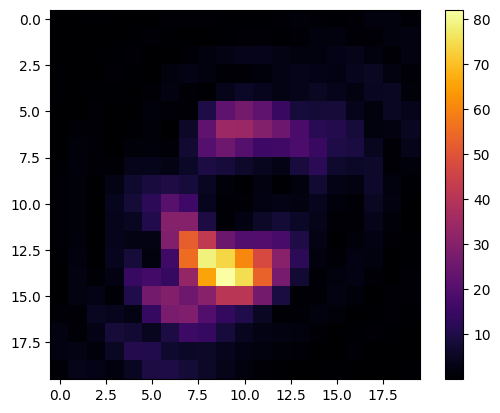

In [578]:
plt.imshow(new_imgs[6][2], cmap='inferno')
plt.colorbar()
plt.show()

In [549]:
TEST_INDEX = 5

imgs_norm.shape = torch.Size([1, 20, 20, 3])
MSE: nan
tensor([[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
         nan]])
[-3.37502742e-08 -2.08598609e-08  3.01202377e-08  2.94590779e-08
  4.92308404e-10 -1.48333535e-11 -2.15820902e-08 -1.11465174e-08
 -1.97141200e-08  1.29215708e-08 -7.44700179e-10  2.87902539e-08
 -2.80508714e-09  2.23483575e-08 -1.14428051e-08 -2.11510941e-08
  3.09714893e-08 -3.19369432e-09 -3.53411922e-08 -1.55351502e-08
 -2.34285395e-08 -9.17537280e-09  3.26702734e-09 -2.20149970e-08
 -1.25820816e-09]


C:\Users\alexe\AppData\Local\Temp\ipykernel_12096\128001587.py:44: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  print(f"MSE: {np.linalg.norm(y_pred - (original - y_mean) / (y_std + 1e-12))}")
C:\Users\alexe\AppData\Local\Temp\ipykernel_12096\128001587.py:54: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  env.deformable_mirror.actuators = original - np.array(y_pred[0])


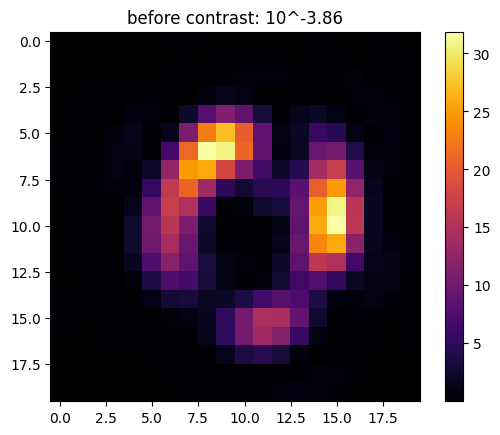

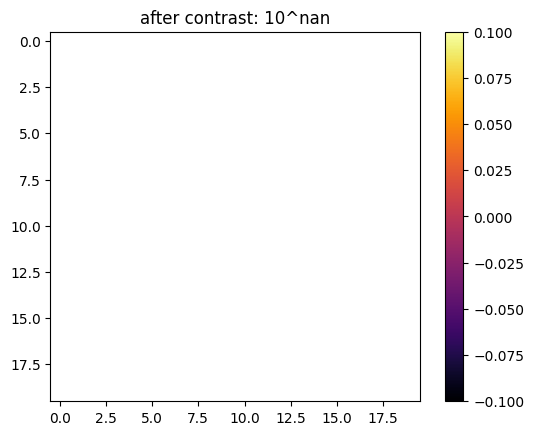

In [550]:
from train_job import NORMALIZERS

nudge_vec = metrics_data['dataset_meta']['nudge_vector']
delta_t = metrics_data['dataset_meta']['dataset_config']['delta_t']
dm_random_noise = metrics_data['dataset_meta']['dataset_config']['dm_random_noise']
N = 1

TEST_INDEX += 1

x_norm_func = NORMALIZERS[metrics_data['x_norm']['type']]
params = metrics_data['x_norm'].copy()
params.pop('type')

y_mean = metrics_data['y_norm']['mean']
y_std = metrics_data['y_norm']['std']

for _ in range(N):
        # env.deformable_mirror.flatten()
        # env.set_random_dm(noise=dm_random_noise)
        # original = env.deformable_mirror.actuators.copy()
        original = dataset['dm_settings'][TEST_INDEX]
        env.set_dm(action=original)

        original_contrast = env.get_contrast(delta_t=1e15)

        img1 = new_imgs[TEST_INDEX][0]


        img2 = new_imgs[TEST_INDEX][1]

        # img2 = torch.asarray(env.get_camera_image(delta_t=delta_t, noise_enabled=False), dtype=torch.float)
        img3 = new_imgs[TEST_INDEX][2]
        # img3 = torch.asarray(env.get_camera_image(delta_t=delta_t, noise_enabled=False), dtype=torch.float)
        
        with torch.no_grad():
            imgs = np.array([img1, img2, img3])
            imgs = torch.asarray(imgs, dtype=torch.float).unsqueeze(0)
            
            imgs_norm, _ = x_norm_func(imgs, **params)
            imgs_norm = np.transpose(imgs_norm, (0, 2, 3, 1))
            print(f"imgs_norm.shape = {imgs_norm.shape}")
            y_pred = model(imgs_norm)

            print(f"MSE: {np.linalg.norm(y_pred - (original - y_mean) / (y_std + 1e-12))}")

            y_pred *= y_std
            y_pred -= y_mean

            print(y_pred)
            print(original)

        
        env.deformable_mirror.flatten()
        env.deformable_mirror.actuators = original - np.array(y_pred[0])
        new_contrast = env.get_contrast(delta_t=1e15)

img4 = torch.asarray(env.get_camera_image(delta_t=delta_t, noise_enabled=False), dtype=torch.float)
plt.imshow(img1, cmap='inferno')
plt.title(f"before contrast: 10^{np.log10(original_contrast):.02f}")
plt.colorbar()
plt.show()

plt.imshow(img4, cmap='inferno')
plt.title(f"after contrast: 10^{np.log10(new_contrast):.02f}")
plt.colorbar()
plt.show()



C:\Users\alexe\AppData\Local\Temp\ipykernel_12096\493405205.py:45: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  print(f"MSE: {np.linalg.norm(y_pred - (original - y_mean) / (y_std + 1e-12))}")
C:\Users\alexe\AppData\Local\Temp\ipykernel_12096\493405205.py:55: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  env.deformable_mirror.actuators = original - 1.0 * np.array(y_pred[0])


MSE: nan
MSE: nan
MSE: nan
MSE: nan
MSE: nan
MSE: nan
MSE: nan
MSE: nan
MSE: nan
MSE: nan


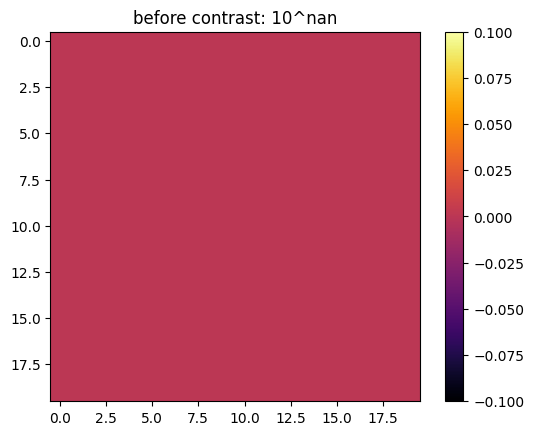

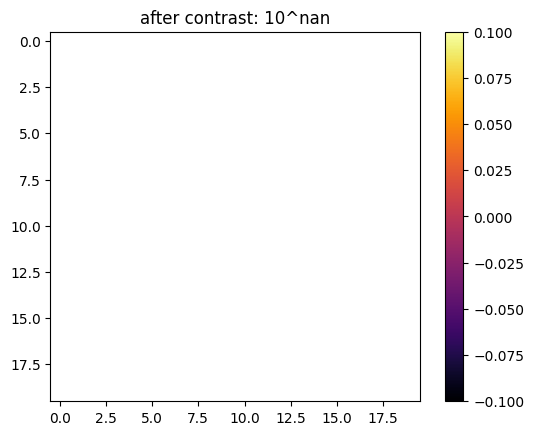

In [551]:
from train_job import NORMALIZERS

nudge_vec = metrics_data['dataset_meta']['nudge_vector']
delta_t = metrics_data['dataset_meta']['dataset_config']['delta_t']
dm_random_noise = metrics_data['dataset_meta']['dataset_config']['dm_random_noise']
N = 10

x_norm_func = NORMALIZERS[metrics_data['x_norm']['type']]
params = metrics_data['x_norm'].copy()
params.pop('type')

y_mean = metrics_data['y_norm']['mean']
y_std = metrics_data['y_norm']['std']

for _ in range(N):
        # env.deformable_mirror.flatten()
        # env.noise_gen_mirror.flatten()
        # env.set_random_dm(noise=1e-7)
        env.set_nudge_vectors(vectors=[nudge_vec])
        original = env.deformable_mirror.actuators.copy()

        original_contrast = env.get_contrast(delta_t=1e15)

        imgs = env.generate_diversity_images(delta_t=delta_t, noise_enabled=False)
        
        # img1 = torch.asarray(env.get_camera_image(delta_t=delta_t, noise_enabled=False), dtype=torch.float)

        # env.deformable_mirror.flatten()
        # env.deformable_mirror.actuators = original + nudge_vec
        # img2 = torch.asarray(env.get_camera_image(delta_t=delta_t, noise_enabled=False), dtype=torch.float)

        # env.deformable_mirror.flatten()
        # env.deformable_mirror.actuators = original - nudge_vec
        # img3 = torch.asarray(env.get_camera_image(delta_t=delta_t, noise_enabled=False), dtype=torch.float)
        
        with torch.no_grad():
            # imgs = np.array([img1, img2, img3])
            imgs = torch.asarray(imgs).unsqueeze(0)
            
            imgs_norm, _ = x_norm_func(imgs, **params)
            imgs_norm = np.transpose(imgs_norm, (0, 2, 3, 1))
            # print(f"imgs_norm.shape = {imgs_norm.shape}")
            y_pred = model(imgs_norm)

            print(f"MSE: {np.linalg.norm(y_pred - (original - y_mean) / (y_std + 1e-12))}")

            y_pred *= y_std
            y_pred -= y_mean

            # print(y_pred)
            # print(original)

        
        env.deformable_mirror.flatten()
        env.deformable_mirror.actuators = original - 1.0 * np.array(y_pred[0])
        new_contrast = env.get_contrast(delta_t=1e15)

img4 = torch.asarray(env.get_camera_image(delta_t=delta_t, noise_enabled=False), dtype=torch.float)
plt.imshow(imgs[0][0], cmap='inferno')
plt.title(f"before contrast: 10^{np.log10(original_contrast):.02f}")
plt.colorbar()
plt.show()

plt.imshow(img4, cmap='inferno')
plt.title(f"after contrast: 10^{np.log10(new_contrast):.02f}")
plt.colorbar()
plt.show()

In [33]:
env.deformable_mirror.flatten()
env.noise_gen_mirror.flatten()
np.log10(env.get_contrast(delta_t=1e15))

np.float64(-8.195727883263018)

imgs_norm.shape = torch.Size([1, 20, 20, 3])
MSE: 5.7836915074366715
tensor([[ 7.1699e-08, -2.9712e-10, -4.9125e-08, -1.5168e-09, -2.0657e-08,
         -9.4145e-09, -2.1485e-08, -5.9218e-09, -3.8495e-08, -7.5642e-09,
          3.8420e-08,  1.5371e-11,  1.9190e-11,  8.5696e-09, -1.4189e-10,
         -3.3656e-08,  5.9560e-09, -5.3455e-09, -1.8570e-09, -1.1514e-10,
         -1.8697e-09, -2.1866e-08, -2.0594e-09, -5.1476e-12, -5.3497e-09]])
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0.]


C:\Users\alexe\AppData\Local\Temp\ipykernel_12096\3645116021.py:44: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  print(f"MSE: {np.linalg.norm(y_pred - (original - y_mean) / y_std)}")
C:\Users\alexe\AppData\Local\Temp\ipykernel_12096\3645116021.py:54: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  env.deformable_mirror.actuators = original - np.array(y_pred[0])


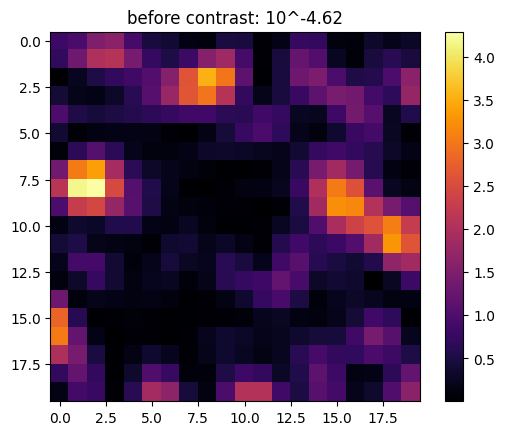

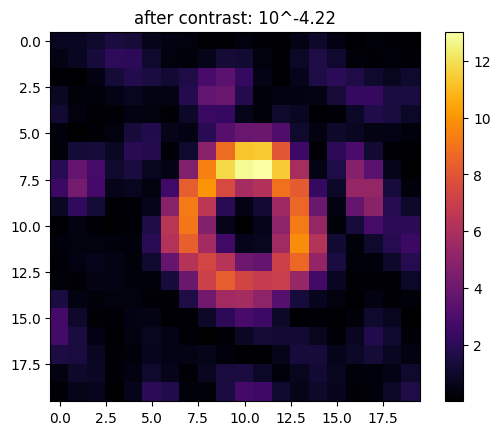

In [332]:
from train_job import NORMALIZERS

nudge_vec = metrics_data['dataset_meta']['nudge_vector']
delta_t = metrics_data['dataset_meta']['dataset_config']['delta_t']
dm_random_noise = metrics_data['dataset_meta']['dataset_config']['dm_random_noise']
N = 1

x_norm_func = NORMALIZERS[metrics_data['x_norm']['type']]
params = metrics_data['x_norm'].copy()
params.pop('type')

y_mean = metrics_data['y_norm']['mean']
y_std = metrics_data['y_norm']['std']

for _ in range(N):
        env.deformable_mirror.flatten()
        env.noise_gen_mirror.flatten()
        env.set_random_noise_dm(noise=1e-7)
        original = env.deformable_mirror.actuators.copy()

        original_contrast = env.get_contrast(delta_t=1e15)
        env.set_nudge_vectors(vectors=[nudge_vec])
        img1g, img2g, img3g = env.generate_diversity_images(delta_t=delta_t, noise_enabled=False)

        img1 = torch.asarray(env.get_camera_image(delta_t=delta_t, noise_enabled=False), dtype=torch.float)

        env.deformable_mirror.flatten()
        env.deformable_mirror.actuators = original + nudge_vec
        img2 = torch.asarray(env.get_camera_image(delta_t=delta_t, noise_enabled=False), dtype=torch.float)

        env.deformable_mirror.flatten()
        env.deformable_mirror.actuators = original - nudge_vec
        img3 = torch.asarray(env.get_camera_image(delta_t=delta_t, noise_enabled=False), dtype=torch.float)
        
        with torch.no_grad():
            imgs = np.array([img1, img2, img3])
            imgs = torch.asarray(imgs).unsqueeze(0)
            
            imgs_norm, _ = x_norm_func(imgs, **params)
            imgs_norm = np.transpose(imgs_norm, (0, 2, 3, 1))
            print(f"imgs_norm.shape = {imgs_norm.shape}")
            y_pred = model(imgs_norm)

            print(f"MSE: {np.linalg.norm(y_pred - (original - y_mean) / y_std)}")

            y_pred *= y_std
            y_pred -= y_mean

            print(y_pred)
            print(original)

        
        env.deformable_mirror.flatten()
        env.deformable_mirror.actuators = original - np.array(y_pred[0])
        new_contrast = env.get_contrast(delta_t=1e15)

        img4 = torch.asarray(env.get_camera_image(delta_t=delta_t, noise_enabled=False), dtype=torch.float)
        plt.imshow(img1, cmap='inferno')
        plt.title(f"before contrast: 10^{np.log10(original_contrast):.02f}")
        plt.colorbar()
        plt.show()

        plt.imshow(img4, cmap='inferno')
        plt.title(f"after contrast: 10^{np.log10(new_contrast):.02f}")
        plt.colorbar()
        plt.show()

